In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# LU decomposition
(only for square matrix A)

A = Lower * Upper triangular 

PA = LU (P -> Permutation matrix's)

Solving with LU

-> Factor once A = LU

-> for each b; Ly = b (forward elimination)

-> then slove Ux = y (backward elimination)

In [ ]:
def matrix_elimination(A, n):
    A = A.astype(float)
    for i in range(n):
        for j in range(i+1, n):
            factor = A[j,i]/A[i,i]
            A[j] = A[j] - factor * A[i]
    
    return A

# x + 3y = -1 and 4x + 7y = 3
# Ax = b

A = np.array([[1,3],
              [4,3]])
b = np.array([1,0])
n = A.shape[0]
U = matrix_elimination(A, n)

# x = np.linalg.solve(U, b)
print(f"U =\n {U}")
# print(f"x1, x2 = {x}")

# # Lower triangular matrix
for j in range(A.shape[0]):
    A[j, j+1:] = 0
# OR
# np.tril(A)

# # Upper triangular matrix
# for i in range(A.shape[0]):
#     A[i, :i] = 0
# OR
# np.triu(A)


U =
 [[ 1.  3.]
 [ 0. -9.]]


# QR decomposition
A = QR  (any matrix)

Q -> Orthogonal
R -> Upper triangular

In [ ]:
A = np.array([[1,5],[8,3]])
Q, R = np.linalg.qr(A)
v1 = Q[:, 0]
v2 = Q[:, 1]
print(f"v1 and v2 are perpendicular to each other: {np.all(v1@v2, 0)}")
print(f"Q =\n {Q}")
print(f"R =\n {R}")

v1 and v2 are perpendicular to each other: True
Q =
 [[-0.12403473 -0.99227788]
 [-0.99227788  0.12403473]]
R =
 [[-8.06225775 -3.5970073 ]
 [ 0.         -4.58928518]]


# Gram-Schmidt process
Gram-Schmidt process: It built a set of orthogonal vector {q1,q2,q3,....,qn}. It itertively subtracts projections from the new vector.

Why we always project the new vectors onto previous basis vectors because removing previous vector direction from the new vector. 

u2 = v2 - proj_v2_on_u1 

Basically, this algorithm used to constructs Q is called Gram-Schmidt.

In [25]:
A = np.array([[5,2],
              [2,4]])
# columns
v1 = A[0:, 0]
v2 = A[0:, 1]

u1 = v1 # keep reference of v1 vector

# calcualting projection v2 onto u1
proj_v2_on_u1 = np.dot(v2,u1)/np.linalg.norm(u1)**2 * u1

# removing the component of vector(v2) along the direction of previous(v1 or u1)
u2 = v2 - proj_v2_on_u1

# calculating orthonormal vectors q1 and q2
q1 =  u1/np.linalg.norm(u1)
q2 = u2/np.linalg.norm(u2)

# output
Q = np.array([q1,q2])
print(Q)
print(np.round(np.dot(q1,q2)))

[[ 0.92847669  0.37139068]
 [-0.37139068  0.92847669]]
-0.0


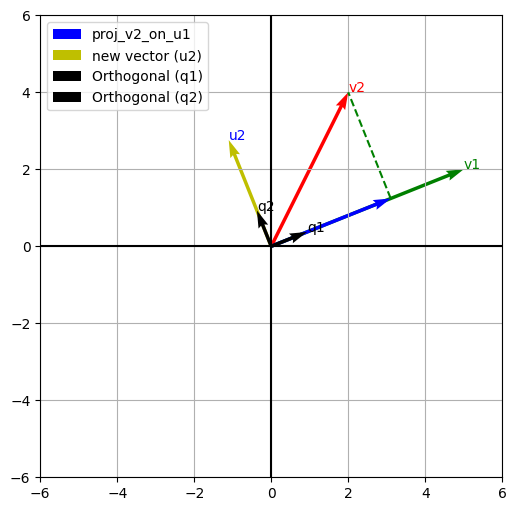

In [26]:
origin = np.zeros(v1.shape)
fig,ax = plt.subplots(figsize=(8,6))

ax.quiver(*origin, *v1, angles='xy', scale_units='xy', scale=1, color='g')
ax.quiver(*origin, *v2, angles='xy', scale_units='xy', scale=1, color='r')
ax.quiver(*origin, *proj_v2_on_u1, angles='xy', scale_units='xy', scale=1, color='b', label='proj_v2_on_u1')
ax.plot([proj_v2_on_u1[0],v2[0]], [proj_v2_on_u1[1], v2[1]], 'g--')
ax.quiver(*origin, *u2, angles='xy', scale_units='xy', scale=1, color='y', label='new vector (u2)')
ax.quiver(*origin, *q1, angles='xy', scale_units='xy', scale=1, color='k', label='Orthogonal (q1)')
ax.quiver(*origin, *q2, angles='xy', scale_units='xy', scale=1, color='k', label='Orthogonal (q2)')


# axes
ax.axhline(0, color='k')
ax.axvline(0, color='k')

# style
ax.grid()
ax.set_xlim(-6,6)
ax.set_ylim(-6,6)
ax.set_aspect('equal')

# text
ax.text(v1[0], v1[1], s='v1', color='g')
ax.text(v2[0], v2[1], s='v2', color='r')
ax.text(u2[0], u2[1], s='u2', color='b')
ax.text(q1[0], q1[1], s='q1', color='k')
ax.text(q2[0], q2[1], s='q2', color='k')

# text representation
ax.legend()

plt.show()